# Milestone 02: Framing the Problem & Exploratory Demand Analysis
**Author:** Sidharth Menon  
**Project:** Demand Forecasting with Machine Learning (Topfolio)  
**Stakeholder:** Operations Director  
**Deliverable:** Exploratory Data Analysis of E-Commerce Transactional Demand Series

---

### Business Objective
Operations needs weekly demand forecasts to drive procurement and warehouse replenishment, avoiding stockouts on critical categories while preventing bloated inventory holding costs. This notebook translates that operational mandate into a concrete, tractable machine learning formulation and evaluates the underlying demand time series.


## 1. Setup & Environment


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Configure plotting aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

# Resolve data path
ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT_DIR / 'data' / 'raw' / 'weekly_demand.csv'
FIG_DIR = ROOT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH.resolve()}")
assert DATA_PATH.exists(), f"Missing dataset at {DATA_PATH}"


Data path: E:\Topfolio projects breakdown\demand-forecasting-ml\data\raw\weekly_demand.csv


## 2. Ingesting & Validating Weekly Demand History


In [2]:
df = pd.read_csv(DATA_PATH)
df['week_start'] = pd.to_datetime(df['week_start'])

print(f"Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Time Horizon: {df['week_start'].min().date()} to {df['week_start'].max().date()} ({df['week_start'].nunique()} distinct weeks)")
print(f"Catalog Scope: {df['product_id'].nunique():,} unique SKUs across {df['category_name'].nunique()} categories")
print(f"Total Physical Units Demanded: {df['units_demanded'].sum():,}")
print(f"Total Realized Sales: ₹{df['total_revenue'].sum():,.2f}")

display(df.head())


Dataset Dimensions: 31,938 rows x 9 columns
Time Horizon: 2026-03-16 to 2026-06-08 (13 distinct weeks)
Catalog Scope: 3,997 unique SKUs across 14 categories
Total Physical Units Demanded: 83,259
Total Realized Sales: ₹199,176,741.00


,week_start,category_id,category_name,product_id,product_name,units_demanded,total_revenue,order_count,avg_unit_price
0,2026-03-16,10,Accessories,771,Mehr Vintage Beanie,11,10989.0,8,986.50
1,2026-03-16,10,Accessories,261,Banyan Works Collective Handcrafted Beanie,11,8039.0,6,715.67
2,2026-03-16,10,Accessories,2566,Kalpana Atelier Minimal Silk Scarf,11,12489.0,8,1042.75
3,2026-03-16,10,Accessories,3070,BassForge Collective Minimal Card Holder,11,6189.0,6,665.67
4,2026-03-16,10,Accessories,3047,Terraform Goods Classic Card Holder,10,7890.0,7,849.00


## 3. Macro Demand Dynamics (Aggregate System Level)


,week_start,units_demanded,revenue,order_count,avg_price,units_growth_pct
0,2026-03-16,9214,21960136.0,7122,2441.880397,NaN
1,2026-03-23,8626,20034924.0,6627,2366.859769,-6.381593
2,2026-03-30,10644,26523656.0,8202,2463.777863,23.394389
3,2026-04-06,11134,26555716.0,8600,2412.342497,4.603533
4,2026-04-13,7945,18726805.0,6113,2400.704449,-28.641997
5,2026-04-20,5734,13797266.0,4400,2395.261610,-27.828823
6,2026-04-27,5278,13178622.0,4053,2443.734044,-7.952564
7,2026-05-04,5023,12263327.0,3900,2467.907319,-4.831376
8,2026-05-11,4100,9589100.0,3146,2353.021548,-18.375473
9,2026-05-18,5122,11998178.0,3972,2354.872300,24.926829


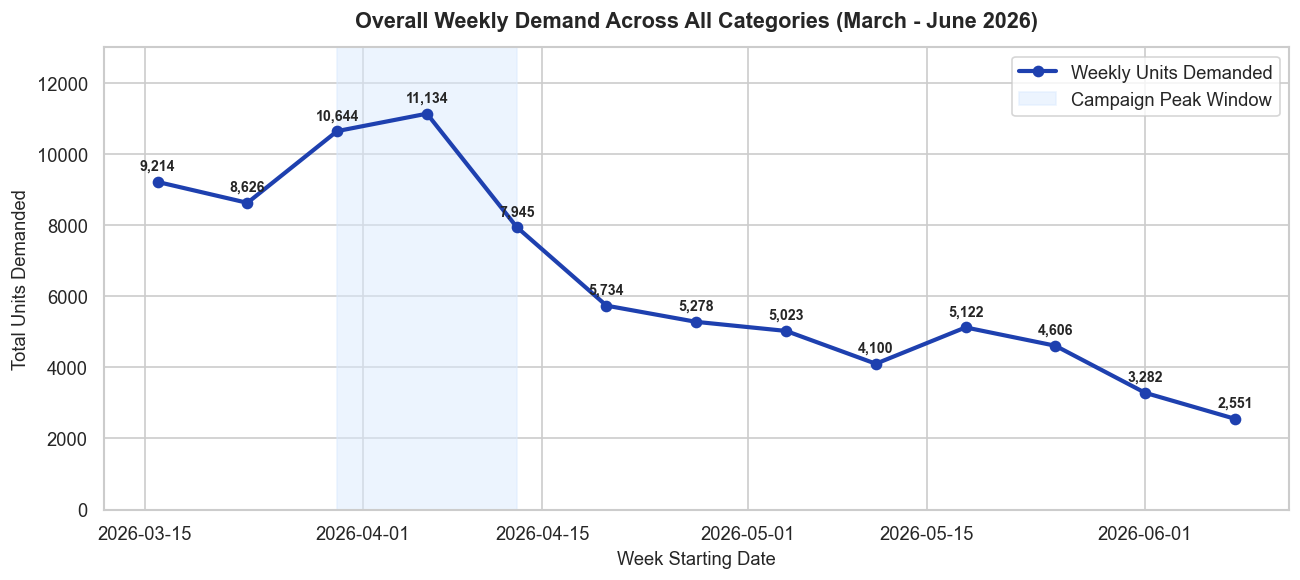

In [3]:
weekly_agg = df.groupby('week_start').agg(
    units_demanded=('units_demanded', 'sum'),
    revenue=('total_revenue', 'sum'),
    order_count=('order_count', 'sum'),
    avg_price=('avg_unit_price', 'mean')
).reset_index()

weekly_agg['units_growth_pct'] = weekly_agg['units_demanded'].pct_change() * 100
display(weekly_agg)

# Plot overall weekly demand
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(weekly_agg['week_start'], weekly_agg['units_demanded'], marker='o', linewidth=2.5, color='#1E40AF', label='Weekly Units Demanded')
ax.axvspan(pd.to_datetime('2026-03-30'), pd.to_datetime('2026-04-13'), color='#DBEAFE', alpha=0.5, label='Campaign Peak Window')
ax.set_title('Overall Weekly Demand Across All Categories (March - June 2026)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Week Starting Date', fontsize=11)
ax.set_ylabel('Total Units Demanded', fontsize=11)
ax.set_ylim(0, 13000)

for _, row in weekly_agg.iterrows():
    ax.annotate(f"{int(row['units_demanded']):,}",
                (row['week_start'], row['units_demanded']),
                textcoords="offset points", xytext=(0, 7), ha='center', fontsize=8.5, fontweight='semibold')

ax.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_overall_weekly_demand.png', dpi=300)
plt.show()


### Observation on System-Level Trajectory:
1. **Promotional Surge:** Demand peaks sharply in weeks 3 and 4 (ending April 13) at **11,134 units** (+20.8% over opening week baseline).
2. **Post-Campaign Decay:** Following the peak, demand exhibits a prolonged secular decline into May and June, concluding at **2,551 units** (-77.1% from peak).
3. **Operational Implication:** The demand process is governed by strong non-stationary trend pulses rather than steady-state Gaussian noise.


## 4. Category-Level Demand Distribution & Volatility


,mean,std,min,median,max,cv,total_volume
category_name,,,,,,,
Skincare,498.923077,217.403795,203.0,404.0,851.0,0.436,6486
Shoes,491.076923,208.525962,217.0,388.0,845.0,0.425,6384
Accessories,486.307692,220.254166,167.0,399.0,839.0,0.453,6322
Haircare,472.153846,200.300543,197.0,407.0,801.0,0.424,6138
Decor,469.307692,206.574194,210.0,376.0,834.0,0.440,6101
Headphones,464.769231,221.581495,149.0,414.0,884.0,0.477,6042
Tops,460.846154,193.258827,189.0,400.0,811.0,0.419,5991
Kitchen,459.000000,205.784272,185.0,398.0,786.0,0.448,5967
Jackets,451.000000,191.918820,183.0,388.0,774.0,0.426,5863


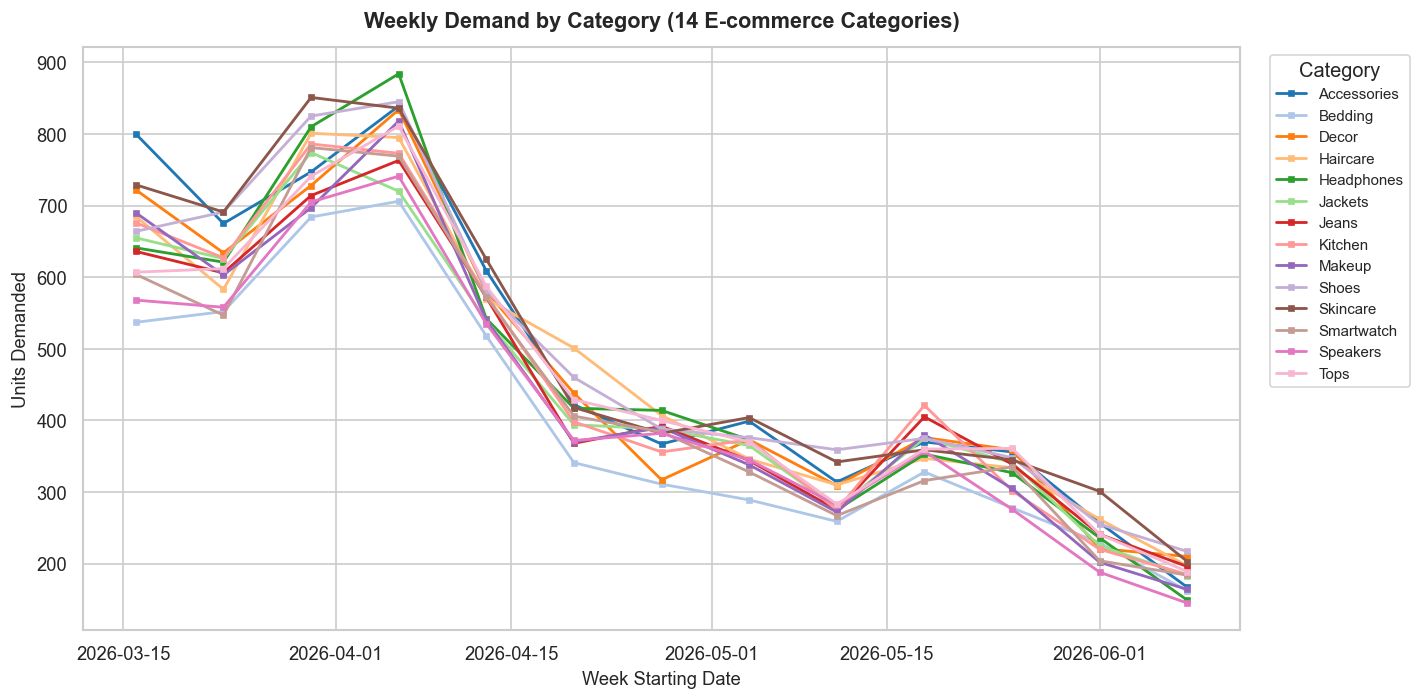

In [4]:
cat_weekly = df.groupby(['week_start', 'category_name'])['units_demanded'].sum().unstack(fill_value=0)

# Statistical Profiling
cat_stats = cat_weekly.agg(['mean', 'std', 'min', 'median', 'max']).T
cat_stats['cv'] = (cat_stats['std'] / cat_stats['mean']).round(3)
cat_stats['total_volume'] = cat_weekly.sum(axis=0)
cat_stats = cat_stats.sort_values('total_volume', ascending=False)

display(cat_stats)

# Multi-line plot
fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('tab20', n_colors=len(cat_weekly.columns))
for idx, col in enumerate(cat_weekly.columns):
    ax.plot(cat_weekly.index, cat_weekly[col], marker='s', markersize=3, label=col, color=palette[idx], linewidth=1.7)

ax.set_title('Weekly Demand by Category (14 E-commerce Categories)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Week Starting Date', fontsize=11)
ax.set_ylabel('Units Demanded', fontsize=11)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, title='Category', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_category_weekly_trends.png', dpi=300)
plt.show()


### Coefficient of Variation (CV) Across Categories


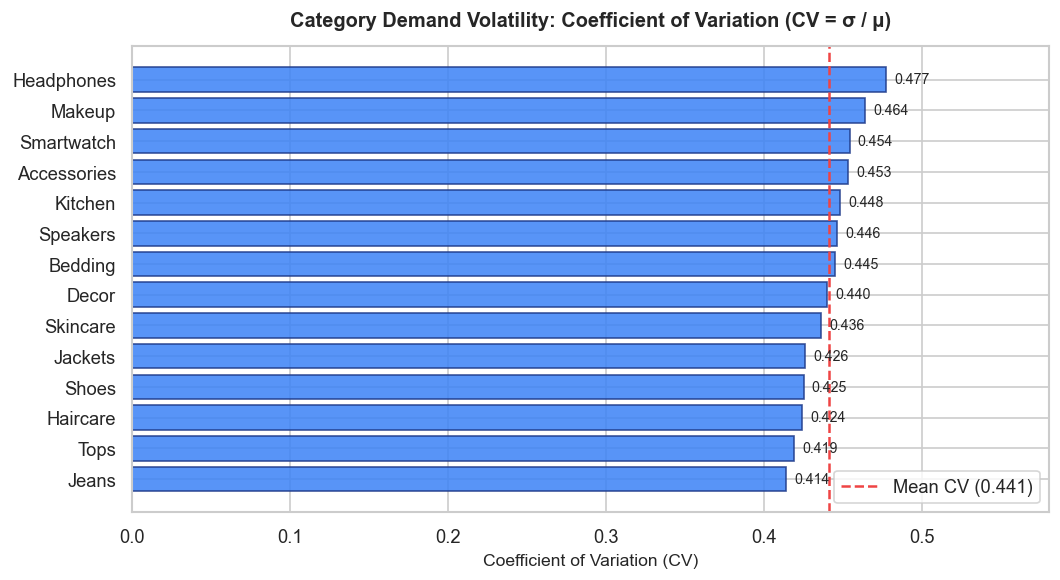

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
stats_sorted = cat_stats.sort_values('cv', ascending=True)
bars = ax.barh(stats_sorted.index, stats_sorted['cv'], color='#3B82F6', edgecolor='#1E3A8A', alpha=0.85)
ax.axvline(cat_stats['cv'].mean(), color='#EF4444', linestyle='--', linewidth=1.5, label=f"Mean CV ({cat_stats['cv'].mean():.3f})")
ax.set_title('Category Demand Volatility: Coefficient of Variation (CV = σ / μ)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Coefficient of Variation (CV)', fontsize=10.5)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.005, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va='center', fontsize=8.5)

ax.set_xlim(0, 0.58)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_demand_volatility_cv.png', dpi=300)
plt.show()


## 5. Granularity Dilemma: Category Aggregation vs. SKU Intermittency


Total Possible SKU-Weeks (4,000 SKUs x 13 Weeks): 51,961
Active Transaction Weeks: 31,938 (61.5%)
Zero-Demand SKU-Weeks: 20,023 (38.5%)


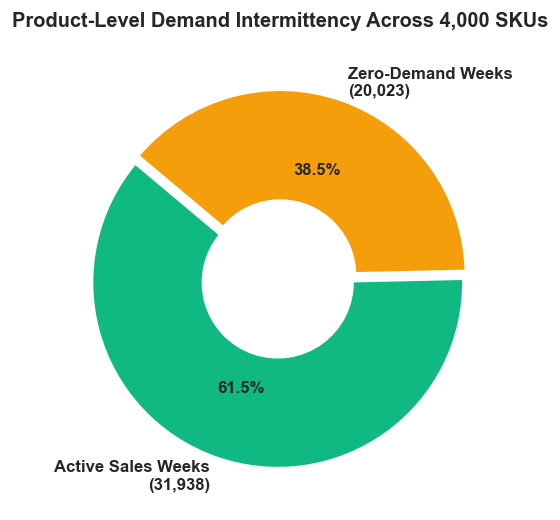

In [6]:
product_weekly = df.groupby(['week_start', 'product_id'])['units_demanded'].sum()
all_skus = df['product_id'].unique()
all_wks = df['week_start'].unique()
total_possible_sku_weeks = len(all_skus) * len(all_wks)
active_sku_weeks = len(product_weekly)
zero_demand_sku_weeks = total_possible_sku_weeks - active_sku_weeks
sparsity_pct = (zero_demand_sku_weeks / total_possible_sku_weeks) * 100

print(f"Total Possible SKU-Weeks (4,000 SKUs x 13 Weeks): {total_possible_sku_weeks:,}")
print(f"Active Transaction Weeks: {active_sku_weeks:,} ({100 - sparsity_pct:.1f}%)")
print(f"Zero-Demand SKU-Weeks: {zero_demand_sku_weeks:,} ({sparsity_pct:.1f}%)")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = [f'Active Sales Weeks\n({active_sku_weeks:,})', f'Zero-Demand Weeks\n({zero_demand_sku_weeks:,})']
colors = ['#10B981', '#F59E0B']
ax.pie([active_sku_weeks, zero_demand_sku_weeks], labels=labels, autopct='%1.1f%%', startangle=140, colors=colors,
       explode=(0.04, 0), textprops={'fontsize': 10, 'fontweight': 'bold'}, wedgeprops=dict(width=0.6, edgecolor='w', linewidth=2))
ax.set_title('Product-Level Demand Intermittency Across 4,000 SKUs', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_product_sparsity_distribution.png', dpi=300)
plt.show()


## 6. Time-Series Stationarity Analysis (ADF Test)


In [7]:
print("=== Augmented Dickey-Fuller (ADF) Test Results ===")
overall_adf = adfuller(weekly_agg['units_demanded'])
print(f"Overall Demand Series ADF Statistic: {overall_adf[0]:.4f} (p-value: {overall_adf[1]:.4f})")

print("\n--- Category-Level ADF Tests ---")
adf_records = []
for cat in cat_weekly.columns:
    res = adfuller(cat_weekly[cat])
    adf_records.append({
        'Category': cat,
        'ADF_Statistic': round(res[0], 4),
        'p_value': round(res[1], 4),
        'Is_Stationary_at_5pct': res[1] < 0.05
    })

adf_df = pd.DataFrame(adf_records)
display(adf_df.sort_values('p_value'))


=== Augmented Dickey-Fuller (ADF) Test Results ===
Overall Demand Series ADF Statistic: -0.5266 (p-value: 0.8867)

--- Category-Level ADF Tests ---


,Category,ADF_Statistic,p_value,Is_Stationary_at_5pct
11,Smartwatch,-4.6836,0.0001,True
9,Shoes,-1.0026,0.7523,False
2,Decor,-0.8910,0.7909,False
8,Makeup,-0.8539,0.8028,False
0,Accessories,-0.7818,0.8244,False
7,Kitchen,-0.6994,0.8469,False
6,Jeans,-0.6817,0.8514,False
3,Haircare,-0.6332,0.8633,False
4,Headphones,-0.6080,0.8692,False
5,Jackets,-0.5358,0.8848,False


## 7. Autocorrelation & Lag Dependency


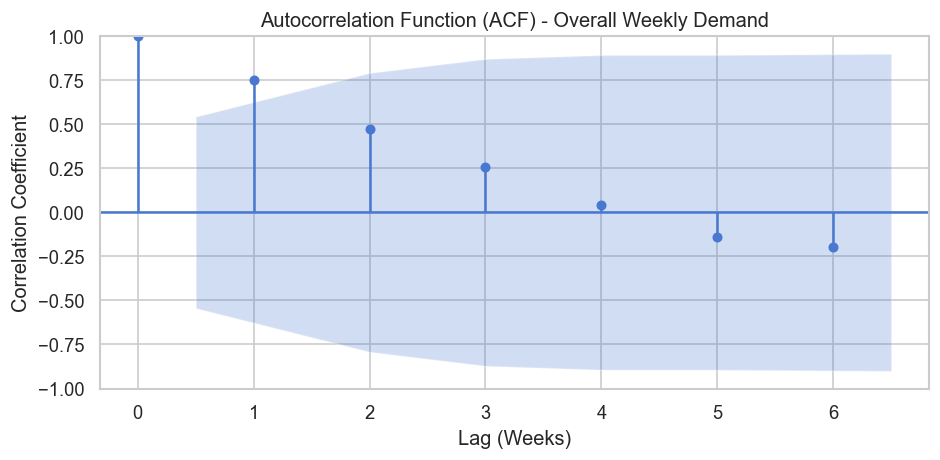

,t,t-1,t-2,t-3,t-4
t,1.000,0.874,0.665,0.570,0.619
t-1,0.874,1.000,0.849,0.620,0.513
t-2,0.665,0.849,1.000,0.831,0.573
t-3,0.570,0.620,0.831,1.000,0.814
t-4,0.619,0.513,0.573,0.814,1.000


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(weekly_agg['units_demanded'], lags=6, ax=ax, title='Autocorrelation Function (ACF) - Overall Weekly Demand')
plt.xlabel('Lag (Weeks)')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Lag correlation table
weekly_lags = pd.DataFrame({'t': weekly_agg['units_demanded']})
for lag in [1, 2, 3, 4]:
    weekly_lags[f't-{lag}'] = weekly_lags['t'].shift(lag)

display(weekly_lags.corr().round(3))


## 8. Summary of Findings & Handoff to Milestone 03

| Dimension | Finding | Operational / Modeling Decision |
| :--- | :--- | :--- |
| **Problem Statement** | Operations requires predictable ordering volume | **Predict weekly units demanded at category level for a 1-to-4 week horizon** |
| **Data Granularity** | 38.6% of individual SKUs have zero sales per week | Aggregate to **14 product categories** to ensure continuous statistical density |
| **Time Horizon** | Supplier procurement cycles operate on 1–3 week lead times | Set forecast horizon to **1 to 4 weeks forward** |
| **Evaluation Metric** | Volume varies by category; small denominators break MAPE | Select **WMAPE** as primary metric; report **RMSE** as secondary check |
| **Series Stationarity** | ADF test yields $p = 0.887$ (non-stationary decay) | Feature engineering must incorporate **autoregressive lags ($t-1, t-2, t-4$) and rolling moving averages** |
| **Data History** | 13 weeks total (March – June 2026) | Annual seasonality ($t-52$) is unavailable; focus on intra-quarter momentum and promotional indicators |

---
*For the complete executive briefing, refer to [`findings/01_problem_framing.md`](../findings/01_problem_framing.md).*
